170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 125ms/step - accuracy: 0.2777 - loss: 1.9317 - val_accuracy: 0.4501 - val_loss: 1.5448
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.4452 - loss: 1.5317 - val_accuracy: 0.5236 - val_loss: 1.3353
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.4919 - loss: 1.4060 - val_accuracy: 0.5890 - val_loss: 1.1378
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 125ms/step - accuracy: 0.5268 - loss: 1.3203 - val_accuracy: 0.6199 - val_loss: 1.0928
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.5543 - loss: 1.2526 - val_accuracy: 0.6128 - val_loss: 1.1093
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.5682 - loss: 1.2089 - val_accuracy: 0.6291 - val_loss: 1.0762
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.5816 - loss: 1.1737 - val_accuracy: 0.6486 - val_loss: 1.0003
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.6023 - loss: 1.1252 - va

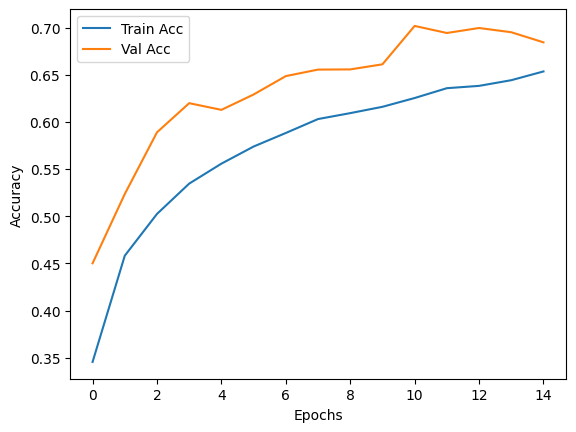

In [ ]:
# Experiment 8: CNN with Data Augmentation

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize images (0-255 -> 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
datagen.fit(x_train)

# 3. Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4. Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train Model with Augmented Data
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=15,
                    validation_data=(x_test, y_test))

# 6. Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# 7. Plot Accuracy & Loss Curves
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 127ms/step - accuracy: 0.2725 - loss: 1.9489 - val_accuracy: 0.4701 - val_loss: 1.4565
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - accuracy: 0.4374 - loss: 1.5491 - val_accuracy: 0.5573 - val_loss: 1.2389
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 126ms/step - accuracy: 0.4978 - loss: 1.4058 - val_accuracy: 0.5945 - val_loss: 1.1363
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 125ms/step - accuracy: 0.5279 - loss: 1.3228 - val_accuracy: 0.5809 - val_loss: 1.1861
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 126ms/step - accuracy: 0.5511 - loss: 1.2534 - val_accuracy: 0.6327 - val_loss: 1.0521
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 133ms/step - accuracy: 0.5734 - loss: 1.1982 - val_accuracy: 0.6482 - val_loss: 0.9908
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.5869 - loss: 1.1681 - val_accuracy: 0.6301 - val_loss: 1.0666
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step - accuracy: 0.6001 - loss: 1.1245 

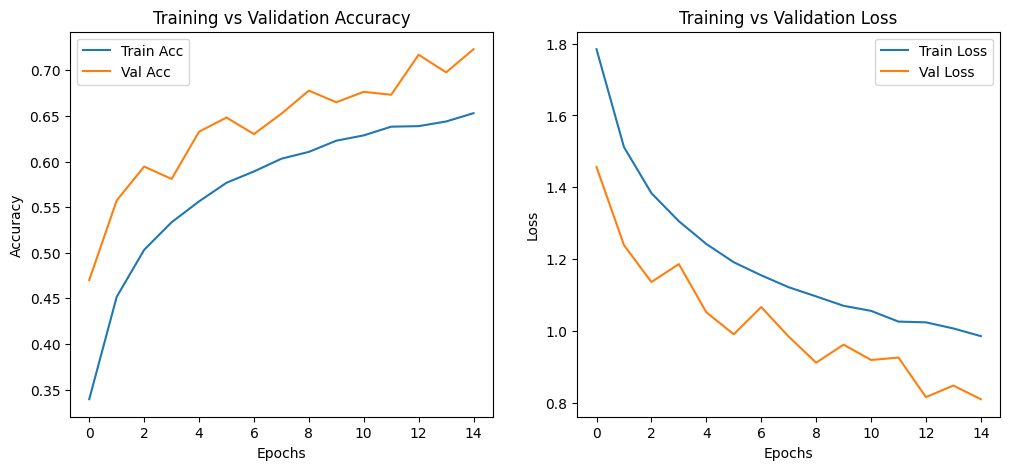

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


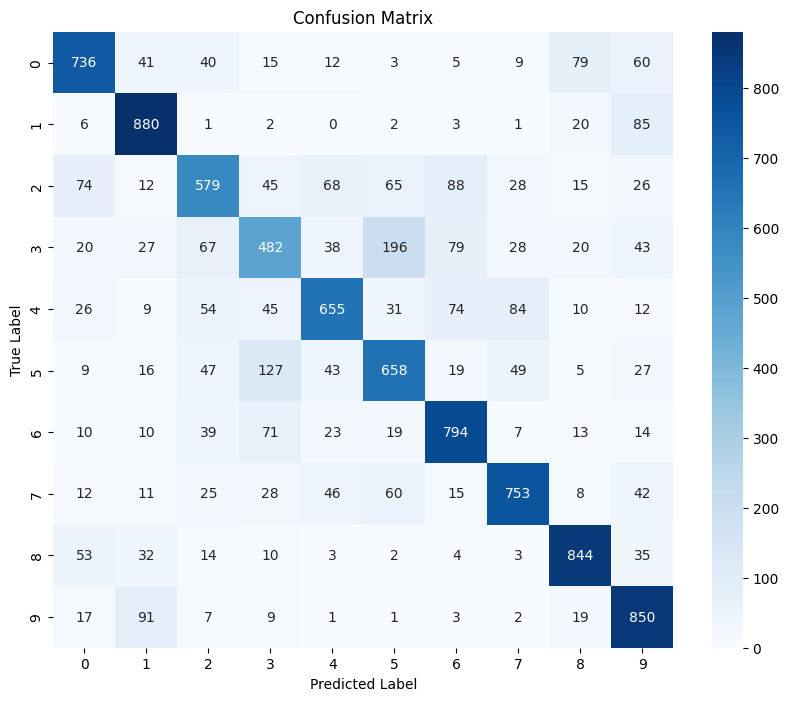


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1000
           1       0.78      0.88      0.83      1000
           2       0.66      0.58      0.62      1000
           3       0.58      0.48      0.53      1000
           4       0.74      0.66      0.69      1000
           5       0.63      0.66      0.65      1000
           6       0.73      0.79      0.76      1000
           7       0.78      0.75      0.77      1000
           8       0.82      0.84      0.83      1000
           9       0.71      0.85      0.77      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



In [ ]:
# Experiment 8: CNN with Data Augmentation

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize images
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
datagen.fit(x_train)

# 3. Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4. Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train Model with Augmented Data
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    epochs=15,
                    validation_data=(x_test, y_test))

# 6. Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

# 7. Plot Accuracy & Loss Curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# 8. Confusion Matrix
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 9. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))
